##PART ONE:
• DOMAIN: Entertainment

• CONTEXT: Company X owns a movie application and repository which caters movie streaming to millions of users who on subscription basis. Company wants to 
automate the process of cast and crew information in each scene from a movie such that when a user pauses on the movie and clicks on cast information 
button, the app will show details of the actor in the scene. Company has an in-house computer vision and multimedia experts who need to detect faces from
screen shots from the movie scene.

• DATA DESCRIPTION: The dataset comprises of images and its mask where there is a human face.

• PROJECT OBJECTIVE: Face detection from training images.

Steps and tasks: [ Total Score: 40 points]
1. Import the dataset.
2. Create features(images) and labels(mask) using that data.
3. Mask detection model:

● Design a face mask detectionmodel.

Hint: Use U-net along with pre-trained transfer learning models

● Design your own Dice Coefficient and Lossfunction.

● Train, tune and test themodel.

● Evaluate the model using testingdata.

4. Use the “Prediction image” as an input to your designed model and display the output of the image.

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import cv2
import numpy as np
import pandas as pd
np.random.seed(1)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import csv
import glob

from keras import Model
from keras.applications.mobilenet import preprocess_input
#from segmentation_models import Unet
from keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten, Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate, LeakyReLU
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from keras.layers import Conv2D, Reshape
# from keras.utils import Sequence
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
import random
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.backend import log, epsilon
from tensorflow.keras.optimizers import Adam, RMSprop

Change Directory

In [41]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment')

###Question #1: Import the dataset.

In [42]:
data=np.load('/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Dataset- Images.npy', allow_pickle=True)

In [5]:
print(data)

[[array([[[42, 37, 34],
        [56, 51, 48],
        [71, 66, 63],
        ...,
        [23, 33, 34],
        [26, 36, 37],
        [28, 38, 39]],

       [[40, 35, 32],
        [51, 46, 43],
        [64, 59, 56],
        ...,
        [27, 36, 35],
        [24, 33, 32],
        [26, 35, 34]],

       [[43, 38, 35],
        [51, 46, 43],
        [61, 56, 53],
        ...,
        [28, 30, 27],
        [33, 35, 32],
        [35, 37, 34]],

       ...,

       [[56, 47, 40],
        [57, 48, 41],
        [61, 52, 45],
        ...,
        [67, 48, 42],
        [55, 35, 28],
        [60, 40, 33]],

       [[53, 44, 37],
        [54, 45, 38],
        [57, 48, 41],
        ...,
        [59, 40, 34],
        [60, 40, 33],
        [54, 34, 27]],

       [[53, 44, 37],
        [54, 45, 38],
        [57, 48, 41],
        ...,
        [59, 40, 34],
        [70, 50, 43],
        [64, 44, 37]]], dtype=uint8)
  list([{'label': ['Face'], 'notes': '', 'points': [{'x': 0.08615384615384615, 'y': 0.3063

In [43]:
# Split the train and test set
X_train, X_test, y_train, y_test = train_test_split(data, list(range(len(data))), test_size=0.10, random_state=50)

###Question #2: Create features (images) and labels (mask) using that data.

Set image dimensions - Initialize image height, image width with value: 224

In [44]:
IMAGE_WIDTH = 224   
IMAGE_HEIGHT = 224 

In [45]:
# Defin the function to split the image and mask. 
def data_prep(imgdata,IMG_HEIGHT,IMG_WIDTH):
  masks = np.zeros((int(imgdata.shape[0]), IMG_HEIGHT, IMG_WIDTH))
  train_data = np.zeros((int(imgdata.shape[0]), IMG_HEIGHT, IMG_WIDTH, 3))

  for index in range(imgdata.shape[0]):
    img = imgdata[index][0]
    img = cv2.resize(img, dsize=(IMG_HEIGHT, IMG_WIDTH), interpolation=cv2.INTER_CUBIC)
    try:
      img = img[:, :, :3]
    except:
        continue
    train_data[index] = preprocess_input(np.array(img, dtype=np.float32))
    for i in imgdata[index][1]:
        x1 = int(i["points"][0]['x'] * IMG_WIDTH)
        x2 = int(i["points"][1]['x'] * IMG_WIDTH)
        y1 = int(i["points"][0]['y'] * IMG_HEIGHT)
        y2 = int(i["points"][1]['y'] * IMG_HEIGHT)
        masks[index][y1:y2, x1:x2] = 1
  return train_data, masks

In [46]:
# Get the image and mask details for training and testing data
trn_data, trn_masks = data_prep(X_train,IMAGE_HEIGHT,IMAGE_WIDTH)
test_data, test_masks = data_prep(X_test,IMAGE_HEIGHT,IMAGE_WIDTH)

In [11]:
print("Training Data Image shape:", trn_data.shape)
print("Training Data Label shape:", trn_masks.shape)
print("Testing Data Image shape:", test_data.shape)
print("Testing Data Label shape:", test_masks.shape)

Training Data Image shape: (368, 224, 224, 3)
Training Data Label shape: (368, 224, 224)
Testing Data Image shape: (41, 224, 224, 3)
Testing Data Label shape: (41, 224, 224)


Print a sample image and image array

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


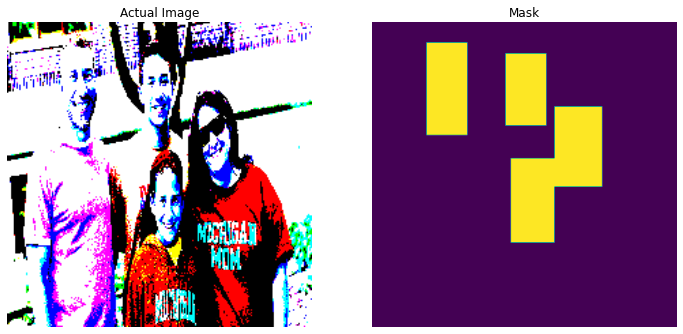

In [64]:
n=5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 8))
ax1.set_title('Actual Image')
ax1.imshow(trn_data[n], interpolation = 'bilinear')
ax1.axis('off')
ax2.set_title('Mask')
ax2.imshow(trn_masks[n],  interpolation = 'bilinear')
ax2.axis('off')
plt.show()

###Question #3#
###Mask detection model:
###● Design a face mask detection model.
###Hint: Use U-net along with pre-trained transfer learning models
###● Design your own Dice Coefficient and Loss function.
###● Train, tune and test the model.
###● Evaluate the model using testing data.

Load VGG16 pre-trained model.
Since we don’t have to train all the layers, we make them non_trainable

In [48]:
basemodel = VGG16(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights="imagenet")

for layer in basemodel.layers:
      layer.trainable = False

58900480/58889256 [==============================] - 1s 0us/step


In [20]:
basemodel.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [49]:
# Build U-net along with pre-trained model
# the bridge (exclude the last maxpooling layer in VGG16) 
tf.keras.backend.clear_session()
bridge = basemodel.get_layer("block5_conv3").output
print(bridge.shape)

# Decoder now
up1 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(bridge)
print(up1.shape)
concat_1 = concatenate([up1, basemodel.get_layer("block4_conv3").output], axis=3)
conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(concat_1)
conv6 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)

up2 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
print(up2.shape)
concat_2 = concatenate([up2, basemodel.get_layer("block3_conv3").output], axis=3)
conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(concat_2)
conv7 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)

up3 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
print(up3.shape)
concat_3 = concatenate([up3, basemodel.get_layer("block2_conv2").output], axis=3)
conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat_3)
conv8 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)

up4 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
print(up4.shape)
concat_4 = concatenate([up4, basemodel.get_layer("block1_conv2").output], axis=3)
conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat_4)
conv9 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)

conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)
print(conv10.shape)

conv10 = Reshape((IMAGE_HEIGHT, IMAGE_WIDTH))(conv10)
 

UnetModel = Model(inputs=[basemodel.input], outputs=[conv10])

(None, 14, 14, 512)
(None, 28, 28, 512)
(None, 56, 56, 256)
(None, 112, 112, 128)
(None, 224, 224, 64)
(None, 224, 224, 1)


In [45]:
# Print Unet Model summary
UnetModel.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 224, 224, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv2 (Conv2D)          (None, 224, 224, 64  36928       ['block1_conv1[0][0]']           
                                )                                                             

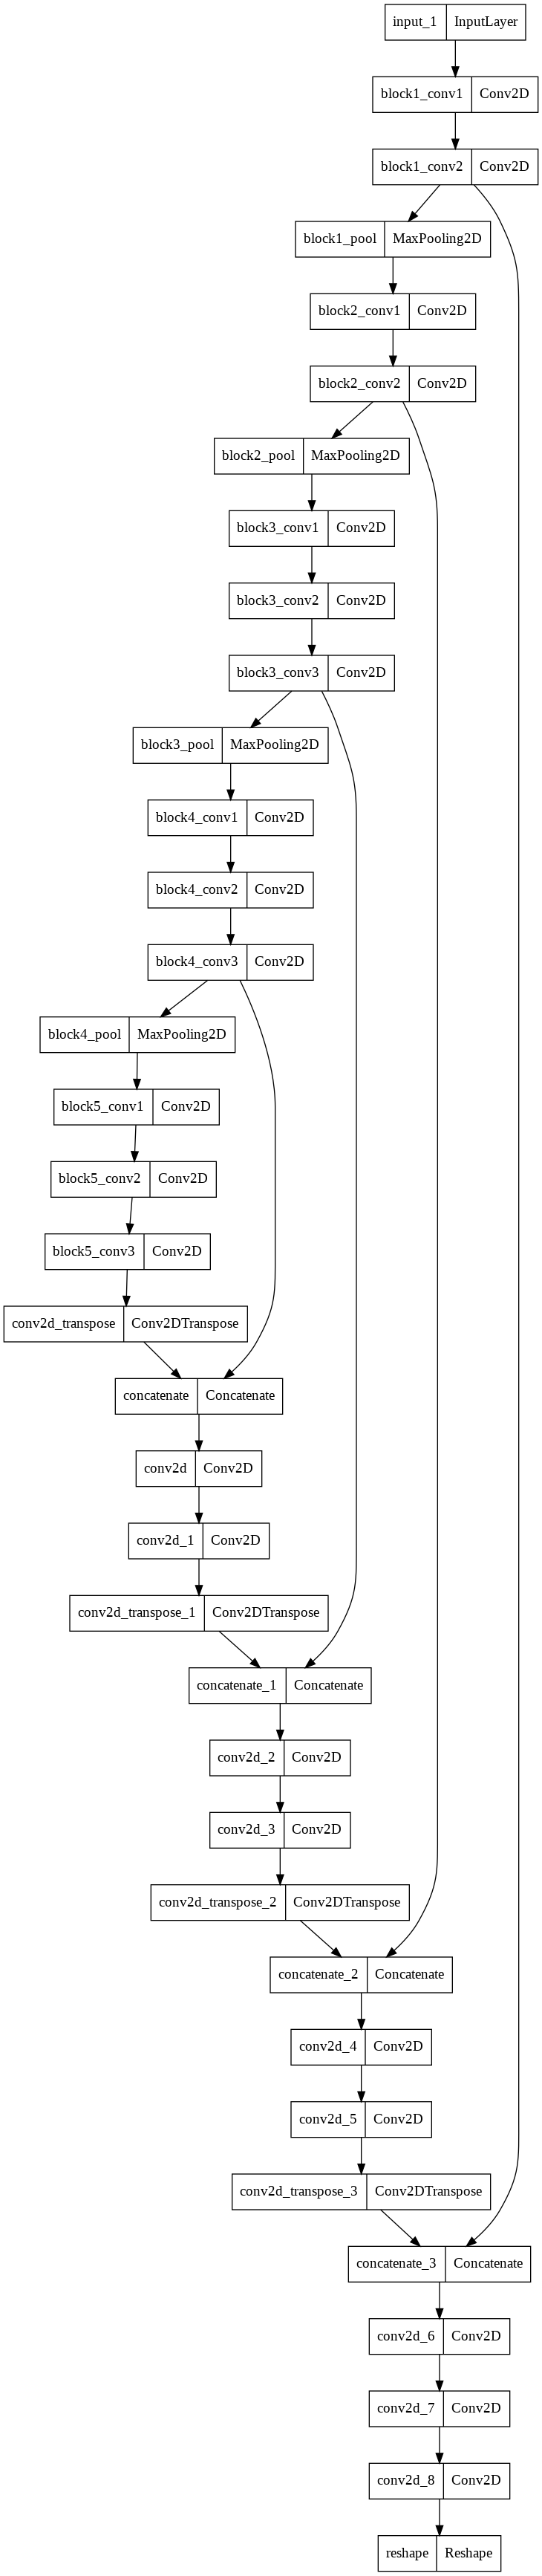

In [50]:
##Pictorial representation of Unet Model + pre-trained Model VGG16**
# Plot the model to view the skeleton 
tf.keras.utils.plot_model(
    UnetModel, to_file='Unetmodel.png', show_shapes=False, show_dtype=False,
    show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)

In [51]:
#Design your own Dice Coefficient and Loss function.
def dice_coefficient(y_true, y_pred):
    #### code added below ####
    import tensorflow
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred)

    return numerator / (denominator + tf.keras.backend.epsilon())
    

In [52]:
#Define Loss function
def loss(y_true, y_pred):
    return binary_crossentropy(y_true, y_pred) - log(dice_coefficient(y_true, y_pred) + epsilon())

In [54]:
#Compile, Train, tune and test the model.

optimizer = RMSprop(learning_rate=0.0001)
#optimizer = Adam(learning_rate=1e-4, beta_1=0.999, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
UnetModel.compile(loss=loss, optimizer=optimizer, metrics=[dice_coefficient])

In [55]:
# Train the model
checkpoint=ModelCheckpoint("Unetmodel.h5", save_best_only=True)
early_stop=EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=200)
history = UnetModel.fit(trn_data,trn_masks,
              validation_data=(test_data, test_masks), epochs=100,batch_size =42, verbose=1, callbacks=[checkpoint, early_stop])

Epoch 1/100
9/9 [==============================] - 138s 11s/step - loss: 6.4927 - dice_coefficient: 0.1279 - val_loss: 4.2583 - val_dice_coefficient: 0.1400
Epoch 2/100
9/9 [==============================] - 25s 3s/step - loss: 4.1032 - dice_coefficient: 0.1600 - val_loss: 3.6342 - val_dice_coefficient: 0.2612
Epoch 3/100
9/9 [==============================] - 24s 3s/step - loss: 3.1895 - dice_coefficient: 0.3064 - val_loss: 2.4567 - val_dice_coefficient: 0.4445
Epoch 4/100
9/9 [==============================] - 24s 3s/step - loss: 2.4841 - dice_coefficient: 0.4212 - val_loss: 2.4363 - val_dice_coefficient: 0.4728
Epoch 5/100
9/9 [==============================] - 24s 3s/step - loss: 2.4931 - dice_coefficient: 0.4270 - val_loss: 2.3507 - val_dice_coefficient: 0.4745
Epoch 6/100
9/9 [==============================] - 24s 3s/step - loss: 2.3826 - dice_coefficient: 0.4518 - val_loss: 2.3137 - val_dice_coefficient: 0.4662
Epoch 7/100
9/9 [==============================] - 22s 2s/step - los

In [39]:
# Evaluate the model #Using Adam optimizer
#UnetModel.evaluate(test_data, test_masks)

2/2 [==============================] - 33s 8s/step - loss: 3.0808 - dice_coefficient: 0.3146


[3.0808193683624268, 0.31463298201560974]

In [56]:
## Evaluate the model using RMSProp optimizer
UnetModel.evaluate(test_data, test_masks)

2/2 [==============================] - 9s 8s/step - loss: 0.9619 - dice_coefficient: 0.7198


[0.9618802070617676, 0.719784140586853]

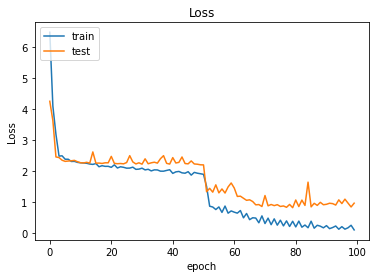

In [57]:
# Plot the graph for Loss vs Val Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

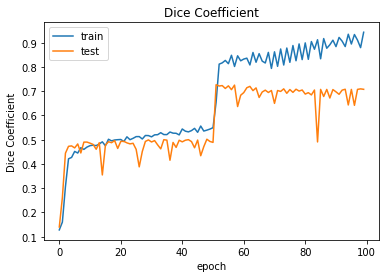

In [58]:
# Plot the graph for Dice Coefficient vs Val Dice Coefficient
plt.plot(history.history['dice_coefficient'])
plt.plot(history.history['val_dice_coefficient'])
plt.title('Dice Coefficient')
plt.ylabel('Dice Coefficient')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


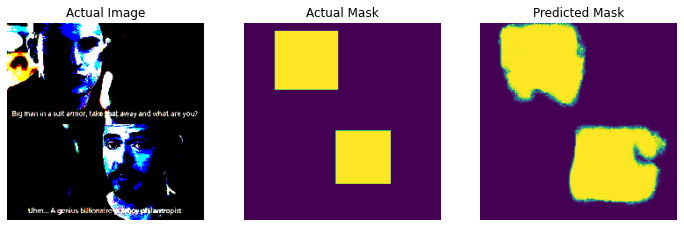

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


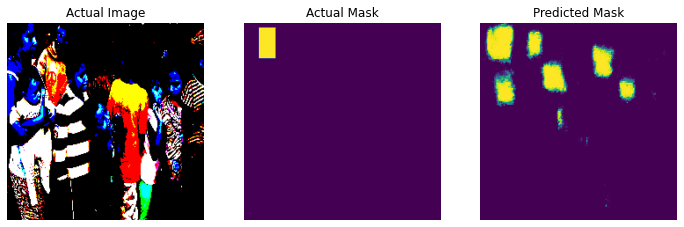

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


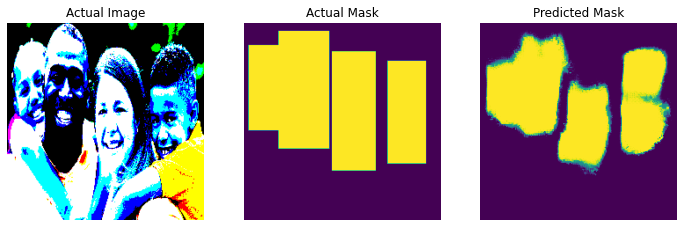

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


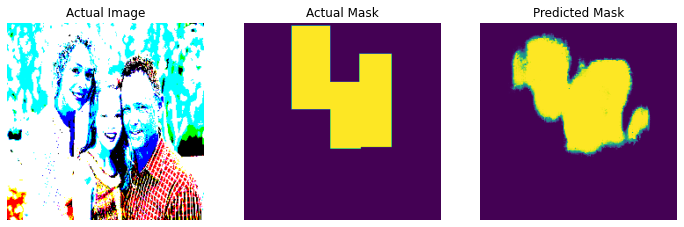

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


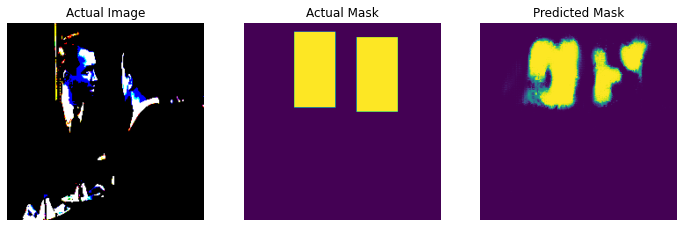

In [59]:
# Test the model with sample images

for i in range(5):
  n = random.randint(0,len(test_data))
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (12, 8))
  ax1.set_title('Actual Image')
  ax1.imshow(test_data[n], interpolation = 'bilinear')
  ax1.axis('off')
  ax2.set_title('Actual Mask')
  ax2.imshow(test_masks[n],  interpolation = 'bilinear')
  ax2.axis('off')
  ax3.set_title('Predicted Mask')
  ax3.imshow(UnetModel.predict(test_data[n].reshape(1,224,224,3)).reshape(224,224),  interpolation = 'bilinear')
  ax3.axis('off')
  plt.show()

###Question #4: Use the “Prediction image” as an input to your designed model and display the output of the imag

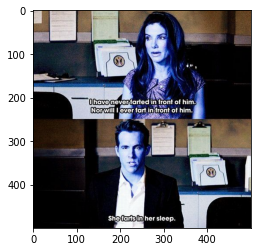

In [60]:
# Load the image
filename = '/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Prediction_Image.jpeg'
unscaled = cv2.imread(filename) # Original image for display
plt.imshow(unscaled)


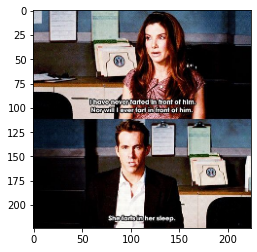

In [61]:
# Resize the image
img_x = cv2.imread(filename)
img_x = cv2.cvtColor(img_x, cv2.COLOR_BGR2RGB)
img_x = cv2.resize(img_x,(224,224))
plt.imshow(img_x)

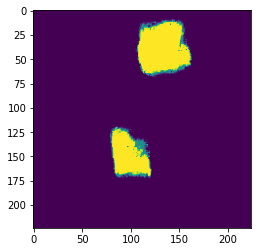

In [63]:
# Predict the mask using the model for above image
PredictMask=UnetModel.predict(img_x.reshape(1,224,224,3))
plt.imshow(PredictMask.reshape(224,224)) 
plt.show()

###Conclusion of PART ONE:
Both RMSProp and Adam optimizer works pretty much same when it comes to detect the object, but could see a variations and has a overfit in the model. Tried with different hyper-parameters and still see model has overfit.

The Face/object detection accuracy is good with VGG16 model. 

Tried with MobileNet pre-trained model and had several errors in compiling the model, hence had to switch to VGG16 which works well in object detection.

The custom Unet model is built on top of VGG16 pretrained model.

##PART TWO:
 DOMAIN: Entertainment
• CONTEXT: Company X owns a movie application and repository which caters movie streaming to millions of users who on subscription basis. Company 
wants to automate the process of cast and crew information in each scene from a movie such that when a user pauses on the movie and clicks on cast 
information button, the app will show details of the actor in the scene. Company has an in-house computer vision and multimedia experts who need to
detect faces from screen shots from the movie scene.
• TASK: Help to create an image dataset to be used by the AI team to build an image classifier data. Profile images of people are given.
1. You are expected to curate the bounding box co-ordinates for each image. These are also called annotations.
2. This task can be done using manual methods where you need to open each image and note the coordinates where the face located [though it is not 
recommended]. This task can be easily done using an automation where you need to input the image in the automation and the output is the
coordinates of the face detected from the image. [this is highly recommended]. Also highlight how many faces detected in each image.

In [1]:
!pip install face-recognition pillow

     |████████████████████████████████| 100.1 MB 26 kB/s 
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566185 sha256=22544da83d0b073b5ad736a5c32163ed85bedb82d088ec6c9b6d1761e8e119c8
  Stored in directory: /root/.cache/pip/wheels/d6/81/3c/884bcd5e1c120ff548d57c2ecc9ebf3281c9a6f7c0e7e7947a
Successfully built face-recognition-models


In [2]:
import cv2
from PIL import *
from PIL import Image, ImageDraw, ImageFont
import face_recognition
import os
import pandas as pd
import matplotlib.patches as patches

###Question #1: You are expected to curate the bounding box co-ordinates for each image. These are also called annotations.

In [3]:
folder = "/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/training_images" 

xmin = []
xmax = []
ymin = []
ymax = []
width = []
height = []
numberofface = []
image_name = []

for filename in os.listdir(folder):
  
  image = face_recognition.load_image_file(os.path.join(folder,filename))
  face_locations = face_recognition.face_locations(image)
  #print(filename)
  #print("Found {} faces in this photograph.".format(len(face_locations)))
  pil_image = Image.fromarray(image)
# Now we will extract bounding box points for all detected faces in image
  for face_location in face_locations:
      # Print the location of each face in this image
      top, right, bottom, left = face_location
    
      # Draw a rectangle using ImageDraw function on image
      shape = [(left, top), (right, bottom)] 
      xmin.append(left)
      xmax.append(right)
      ymin.append(top)
      ymax.append(bottom)
      height.append(bottom - top)
      width.append(right - left)
      numberofface.append(len(face_locations))
      image_name.append(filename)
      #print(shape)
      img1 = ImageDraw.Draw(pil_image)   
    
      # We set outline color as red and width of 4
      img1.rectangle(shape, outline ="red", width=4) 
      # Show final image
      pil_image.show()
      # Save image
      outputimgname = "/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_"+filename
      print(outputimgname)
      pil_image.save(outputimgname)
  

/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00144.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00064.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00046.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00026.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00082.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00037.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00078.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00159.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00049.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/Part2_op/output_real_00086.jpg
/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/da

Highlight number of faces detected in each image

In [13]:
data = {'image_name':image_name,
        'xmin':xmin,
        'xmax':xmax,
        'ymin':ymin,
        'ymax':ymax,
        'width':width,
        'height':height,
        'total_faces':numberofface}

  # Create DataFrame
df = pd.DataFrame(data)

In [14]:
df['total_faces'].value_counts()

1    1016
2       6
Name: total_faces, dtype: int64

In [23]:
print(df.loc[df['total_faces'] > 1])

         image_name  xmin  xmax  ymin  ymax  width  height  total_faces
634  real_00680.jpg   118   504   204   590    386     386            2
635  real_00680.jpg   482   525   382   425     43      43            2
689  real_00921.jpg    33   418   247   600    385     353            2
690  real_00921.jpg    74   117   223   266     43      43            2
944  real_00012.jpg   170   491   241   562    321     321            2
945  real_00012.jpg   515   567   164   216     52      52            2


###Question #2: This task can be easily done using an automation where you need to input the image in the automation and the output is the coordinates of the face detected from the image

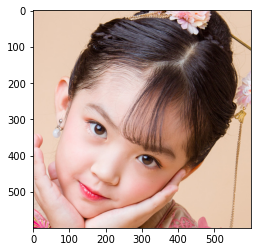

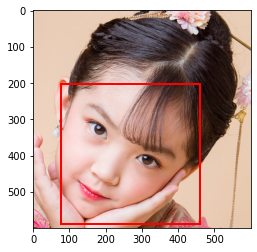

In [33]:
#filename = "/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/training_images/real_00641.jpg"
filename = "/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/training_images/real_00921.jpg"

unscaled = cv2.imread(filename) # Original image for display
unscaled = cv2.cvtColor(unscaled, cv2.COLOR_BGR2RGB)
plt.imshow(unscaled)

# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((df['xmin'][2], df['ymin'][2]), df['width'][2] , df['height'][1] , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()

In [34]:
image = face_recognition.load_image_file("/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/training_images/real_00001.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [35]:
image

array([[[ 93, 186, 201],
        [ 89, 182, 197],
        [ 82, 177, 192],
        ...,
        [139, 156, 213],
        [136, 153, 210],
        [139, 158, 215]],

       [[ 79, 172, 187],
        [ 78, 173, 188],
        [ 79, 174, 189],
        ...,
        [138, 154, 213],
        [134, 150, 209],
        [137, 153, 212]],

       [[ 62, 157, 172],
        [ 67, 162, 177],
        [ 74, 171, 185],
        ...,
        [132, 146, 205],
        [127, 143, 202],
        [131, 147, 206]],

       ...,

       [[107,  75,  99],
        [111,  79, 103],
        [117,  86, 107],
        ...,
        [ 32,  21,  23],
        [ 31,  22,  25],
        [ 32,  23,  26]],

       [[105,  76,  99],
        [109,  80, 103],
        [114,  85, 108],
        ...,
        [ 31,  20,  22],
        [ 31,  22,  25],
        [ 33,  24,  27]],

       [[109,  80, 103],
        [114,  85, 108],
        [119,  90, 113],
        ...,
        [ 30,  19,  21],
        [ 33,  22,  25],
        [ 33,  24,  27]]

In [36]:
face_locations = face_recognition.face_locations(image)
print("Found {} faces in this photograph.".format(len(face_locations)))

Found 1 faces in this photograph.


In [37]:
face_locations

[(162, 546, 547, 161)]

In [38]:
pil_image = Image.fromarray(image)
# Now we will extract bounding box points for all detected faces in image
for face_location in face_locations:
    # Print the location of each face in this image
    top, right, bottom, left = face_location
   
    # Draw a rectangle using ImageDraw function on image
    shape = [(left, top), (right, bottom)] 
    print(shape)
    img1 = ImageDraw.Draw(pil_image)   
  
    # We set outline color as red and width of 4
    img1.rectangle(shape, outline ="red", width=4) 
    # Show final image
    pil_image.show()
    # Save image
    pil_image.save("/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/output.jpg")

[(161, 162), (546, 547)]


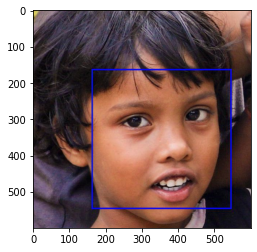

In [39]:
filename = '/content/drive/MyDrive/Colab Notebooks/R10-ACV/Assessment/data/output.jpg'
unscaled = cv2.imread(filename) # Original image for display
plt.imshow(unscaled)

###Question #3: Comment on the challenge faced during this task

1. There was a space issue as there were high number of images provided including part 1 and part 2. 
2. The manual way to draw a bounding box is always challenge to adjust the co-ordinates.
3. It took some time to find right package and function (ImageDraw) to draw a bounding box.
4. As there are 1000+ images, it took a while to plot a boundary box.